# Machine Learning for Biological Modeling
## SIAM Life Sciences 2026 Mini-Tutorial: Machine Learning Section
### Example 1: Classification with Logistic Regression

In this notebook, we build and evaluate classifiers for binary biological outcomes, such as disease vs. healthy tissue or malignant vs. benign tumors.

The main goals are to:

- create a small synthetic classification problem where the true signal is known;
- fit logistic regression models with different feature sets;
- compare train/test performance, cross-validation, and external validation;
- compare logistic regression with other common classifiers;
- apply the same workflow to a real biomedical dataset.


## Imports and Settings


In [10]:
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ranksums
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

RANDOM_STATE = 42

pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid")


## Part 1: A Synthetic Binary Classification Dataset

We start with synthetic data because it lets us know which features truly contain signal. This is useful for teaching: in real biological datasets, we usually do not know the ground truth feature structure.

Here we create 100 observations with 5 measured features. Only the first 2 features are informative; the remaining 3 are noise. The classes are intentionally imbalanced, as many biological and clinical datasets are.


In [11]:
X, y = make_classification(
    n_samples=100,
    n_features=5,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    weights=[0.7, 0.3],
    hypercube=True,
    shift=0.0,
    scale=1.0,
    shuffle=False,
    random_state=RANDOM_STATE,
)

feature_names = [f"Feature_{i+1}" for i in range(X.shape[1])]
X_df = pd.DataFrame(X, columns=feature_names)
y_series = pd.Series(y, name="Class")

print("Class counts:")
display(y_series.value_counts().rename_axis("Class").to_frame("Count"))

display(X_df.head())


Class counts:


,Count
Class,
0,70
1,30


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5
0,-0.679587,-0.816806,-0.315269,0.758969,-0.772825
1,0.088962,-0.071335,-0.236819,-0.485364,0.081874
2,-1.268984,-1.207572,2.314659,-1.867265,0.686260
3,0.494298,0.071236,-1.612716,-0.471932,1.088951
4,-1.140548,-1.006350,0.064280,-1.077745,-0.715304


Because `shuffle=False`, the data-generating process places the informative features first:

- `Feature_1` and `Feature_2` contain signal;
- `Feature_3`, `Feature_4`, and `Feature_5` are noise.

In a real biology problem we would not know this. A simple univariate check can suggest which features differ between classes, but it is not a substitute for model validation.


In [12]:
rank_results = []

for col in X_df.columns:
    class_0 = X_df.loc[y_series == 0, col]
    class_1 = X_df.loc[y_series == 1, col]
    p_value = ranksums(class_0, class_1).pvalue
    mean_difference = class_1.mean() - class_0.mean()

    rank_results.append({
        "Feature": col,
        "Mean difference (Class 1 - Class 0)": mean_difference,
        "Wilcoxon rank-sum p-value": p_value,
    })

rank_results_df = pd.DataFrame(rank_results).sort_values(
    by="Wilcoxon rank-sum p-value"
)

display(rank_results_df)


,Feature,Mean difference (Class 1 - Class 0),Wilcoxon rank-sum p-value
1,Feature_2,2.146757,1.792666e-14
2,Feature_3,-0.279687,7.712497e-02
3,Feature_4,0.125271,5.829440e-01
0,Feature_1,0.109574,6.681116e-01
4,Feature_5,-0.067587,8.982517e-01


## Logistic Regression with Different Feature Sets

Logistic regression estimates the probability that an observation belongs to class 1. We will fit many small models using every 1-, 2-, and 3-feature combination, then rank them by ROC AUC.

First we use a single train/test split. This is a helpful first pass, but the result can depend on which observations land in the test set.


In [13]:
results = []
roc_data = {}
feature_list = X_df.columns.tolist()

for n_features in [1, 2, 3]:
    for feature_combo in combinations(feature_list, n_features):
        feature_name = " + ".join(feature_combo)
        X_subset = X_df[list(feature_combo)]

        X_train, X_test, y_train, y_test = train_test_split(
            X_subset,
            y_series,
            test_size=0.2,
            random_state=RANDOM_STATE,
            stratify=y_series,
        )

        model = make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=1000),
        )

        model.fit(X_train, y_train)

        y_train_prob = model.predict_proba(X_train)[:, 1]
        y_test_prob = model.predict_proba(X_test)[:, 1]

        train_auc = roc_auc_score(y_train, y_train_prob)
        test_auc = roc_auc_score(y_test, y_test_prob)
        fpr, tpr, _ = roc_curve(y_test, y_test_prob)

        results.append({
            "Num Features": n_features,
            "Features": feature_name,
            "Training ROC AUC": train_auc,
            "Testing ROC AUC": test_auc,
        })

        roc_data[feature_name] = {
            "fpr": fpr,
            "tpr": tpr,
            "auc": test_auc,
        }

single_split_results_df = pd.DataFrame(results).sort_values(
    by="Testing ROC AUC",
    ascending=False,
)

display(single_split_results_df.head(10).round(3))

top_single_split_models = single_split_results_df.head(5)

# plt.figure(figsize=(9, 7))
# colors = plt.cm.tab10(np.linspace(0, 1, len(top_single_split_models)))

# for color, (_, row) in zip(colors, top_single_split_models.iterrows()):
#     label = row["Features"]
#     plt.plot(
#         roc_data[label]["fpr"],
#         roc_data[label]["tpr"],
#         color=color,
#         linewidth=2.5,
#         label=f"{label} (AUC = {roc_data[label]['auc']:.2f})",
#     )

# plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1.5, label="Random classifier")
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("Top Logistic Regression Models: Single Train/Test Split")
# plt.legend(loc="lower right")
# plt.tight_layout()
# plt.show()


,Num Features,Features,Training ROC AUC,Testing ROC AUC
15,3,Feature_1 + Feature_2 + Feature_3,1.000,1.000
23,3,Feature_2 + Feature_4 + Feature_5,0.987,1.000
22,3,Feature_2 + Feature_3 + Feature_5,0.992,1.000
21,3,Feature_2 + Feature_3 + Feature_4,0.990,1.000
17,3,Feature_1 + Feature_2 + Feature_5,1.000,1.000
9,2,Feature_2 + Feature_3,0.989,1.000
11,2,Feature_2 + Feature_5,0.987,1.000
16,3,Feature_1 + Feature_2 + Feature_4,1.000,0.988
5,2,Feature_1 + Feature_2,1.000,0.988
10,2,Feature_2 + Feature_4,0.987,0.988


## Cross-Validation for Model Selection

Cross-validation gives a more stable estimate of model performance by repeatedly training and testing on different folds of the same dataset. Here we use stratified folds so that each fold keeps approximately the same class balance.


,Num Features,Features,Mean CV ROC AUC,Std CV ROC AUC
15,3,Feature_1 + Feature_2 + Feature_3,1.000,0.000
26,4,Feature_1 + Feature_2 + Feature_3 + Feature_5,1.000,0.000
25,4,Feature_1 + Feature_2 + Feature_3 + Feature_4,1.000,0.000
5,2,Feature_1 + Feature_2,1.000,0.000
17,3,Feature_1 + Feature_2 + Feature_5,1.000,0.000
16,3,Feature_1 + Feature_2 + Feature_4,1.000,0.000
27,4,Feature_1 + Feature_2 + Feature_4 + Feature_5,0.998,0.005
11,2,Feature_2 + Feature_5,0.988,0.024
23,3,Feature_2 + Feature_4 + Feature_5,0.988,0.024
22,3,Feature_2 + Feature_3 + Feature_5,0.988,0.024


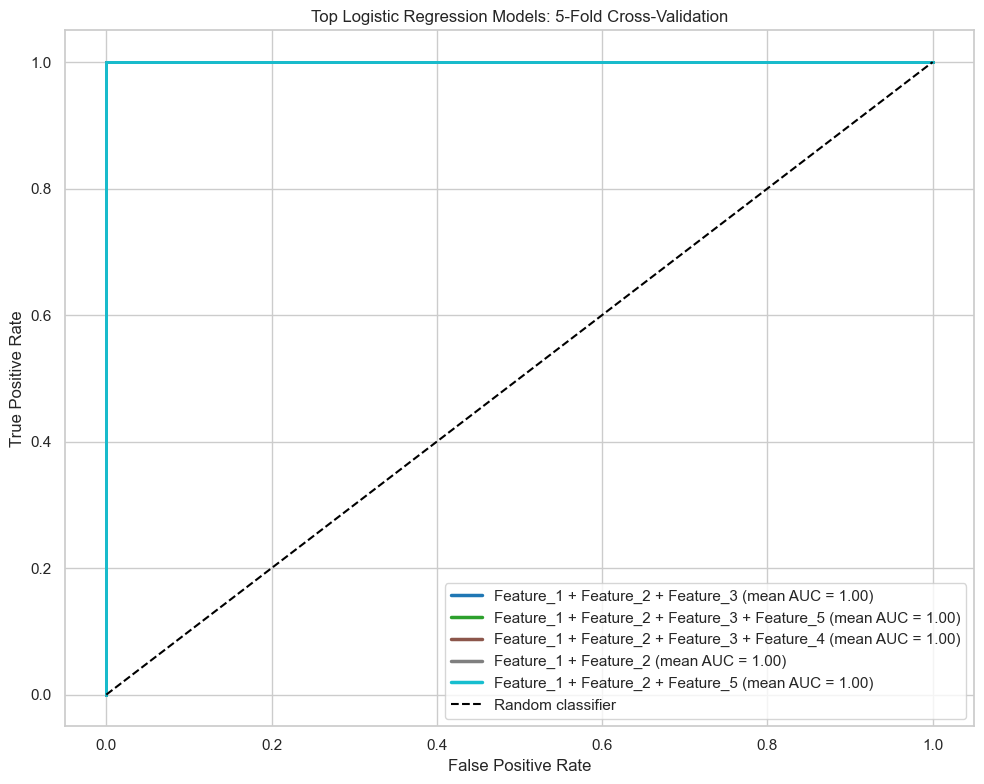

In [18]:
cv_results = []
cv_roc_data = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for n_features in [1, 2, 3, 4]:
    for feature_combo in combinations(feature_list, n_features):
        feature_name = " + ".join(feature_combo)
        X_subset = X_df[list(feature_combo)]

        fold_aucs = []
        fold_rocs = []

        for train_idx, test_idx in cv.split(X_subset, y_series):
            X_train = X_subset.iloc[train_idx]
            X_test = X_subset.iloc[test_idx]
            y_train = y_series.iloc[train_idx]
            y_test = y_series.iloc[test_idx]

            model = make_pipeline(
                StandardScaler(),
                LogisticRegression(max_iter=1000,penalty="l2",C=1.0),
            )

            model.fit(X_train, y_train)
            y_prob = model.predict_proba(X_test)[:, 1]

            auc = roc_auc_score(y_test, y_prob)
            fpr, tpr, _ = roc_curve(y_test, y_prob)

            fold_aucs.append(auc)
            fold_rocs.append((fpr, tpr))

        cv_results.append({
            "Num Features": n_features,
            "Features": feature_name,
            "Mean CV ROC AUC": np.mean(fold_aucs),
            "Std CV ROC AUC": np.std(fold_aucs),
        })

        cv_roc_data[feature_name] = {
            "fold_rocs": fold_rocs,
            "mean_auc": np.mean(fold_aucs),
        }

cv_results_df = pd.DataFrame(cv_results).sort_values(
    by="Mean CV ROC AUC",
    ascending=False,
)

display(cv_results_df.head(10).round(3))

top_cv_models = cv_results_df.head(5)

plt.figure(figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, len(top_cv_models)))

for color, (_, row) in zip(colors, top_cv_models.iterrows()):
    label = row["Features"]
    for fpr, tpr in cv_roc_data[label]["fold_rocs"]:
        plt.plot(fpr, tpr, color=color, linewidth=2, alpha=0.55)

    plt.plot(
        [],
        [],
        color=color,
        linewidth=2.5,
        label=f"{label} (mean AUC = {cv_roc_data[label]['mean_auc']:.2f})",
    )

plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1.5, label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Top Logistic Regression Models: 5-Fold Cross-Validation")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Penalizing Unnecessary Features During Model Selection

The cross-validation table ranks models by mean ROC AUC alone. That can create an important teaching problem: if `Feature_1 + Feature_2 + Feature_3` has the same AUC as `Feature_1 + Feature_2`, the larger model may still appear first just because of tiny numerical differences or sorting order.

For this example, we know only the first two features contain true signal. A model-selection penalty lets us encode the principle that extra features should only be included if they improve validation performance enough to justify the added complexity.

Here we use a simple penalized score:

$$
\text{Penalized score}
=
\text{Mean CV ROC AUC}
-
\lambda \times
\text{Number of features}
$$

The value of $(\lambda)$ controls how strongly we prefer smaller models. The goal is not to change the logistic regression fit itself; the goal is to choose among candidate feature sets more responsibly.


In [19]:
complexity_penalty = 0.005

model_selection_df = cv_results_df.copy()
model_selection_df["Complexity Penalty"] = (
    complexity_penalty * model_selection_df["Num Features"]
)
model_selection_df["Penalized CV Score"] = (
    model_selection_df["Mean CV ROC AUC"] - model_selection_df["Complexity Penalty"]
)

model_selection_df = model_selection_df.sort_values(
    by=["Penalized CV Score", "Mean CV ROC AUC"],
    ascending=False,
)

print(f"Penalty per feature: {complexity_penalty}")
display(
    model_selection_df[
        [
            "Num Features",
            "Features",
            "Mean CV ROC AUC",
            "Complexity Penalty",
            "Penalized CV Score",
        ]
    ]
    .head(10)
    .round(3)
)

selected_model = model_selection_df.iloc[0]

print("Selected model after penalizing extra features:")
print(selected_model["Features"])
print("Mean CV ROC AUC:", round(selected_model["Mean CV ROC AUC"], 3))
print("Penalized CV score:", round(selected_model["Penalized CV Score"], 3))

# Use the penalized ranking for the next section.
top_cv_models = model_selection_df.head(5)


Penalty per feature: 0.005


,Num Features,Features,Mean CV ROC AUC,Complexity Penalty,Penalized CV Score
5,2,Feature_1 + Feature_2,1.000,0.010,0.990
15,3,Feature_1 + Feature_2 + Feature_3,1.000,0.015,0.985
17,3,Feature_1 + Feature_2 + Feature_5,1.000,0.015,0.985
16,3,Feature_1 + Feature_2 + Feature_4,1.000,0.015,0.985
26,4,Feature_1 + Feature_2 + Feature_3 + Feature_5,1.000,0.020,0.980
25,4,Feature_1 + Feature_2 + Feature_3 + Feature_4,1.000,0.020,0.980
1,1,Feature_2,0.983,0.005,0.978
11,2,Feature_2 + Feature_5,0.988,0.010,0.978
27,4,Feature_1 + Feature_2 + Feature_4 + Feature_5,0.998,0.020,0.978
10,2,Feature_2 + Feature_4,0.986,0.010,0.976


Selected model after penalizing extra features:
Feature_1 + Feature_2
Mean CV ROC AUC: 1.0
Penalized CV score: 0.99


## External Validation

Cross-validation helps with model selection, but it still reuses the same dataset. External validation evaluates the chosen model on a separate cohort that was not used during model development.

Here we simulate an external cohort with a different class balance and shifted feature distribution. This mimics a common biological problem: a model developed in one cohort may not perform the same way in another cohort.


,Features,Mean CV ROC AUC,External ROC AUC
0,Feature_1 + Feature_2,1.0,1.000
2,Feature_1 + Feature_2 + Feature_5,1.0,1.000
3,Feature_1 + Feature_2 + Feature_4,1.0,1.000
1,Feature_1 + Feature_2 + Feature_3,1.0,0.995
4,Feature_1 + Feature_2 + Feature_3 + Feature_5,1.0,0.995


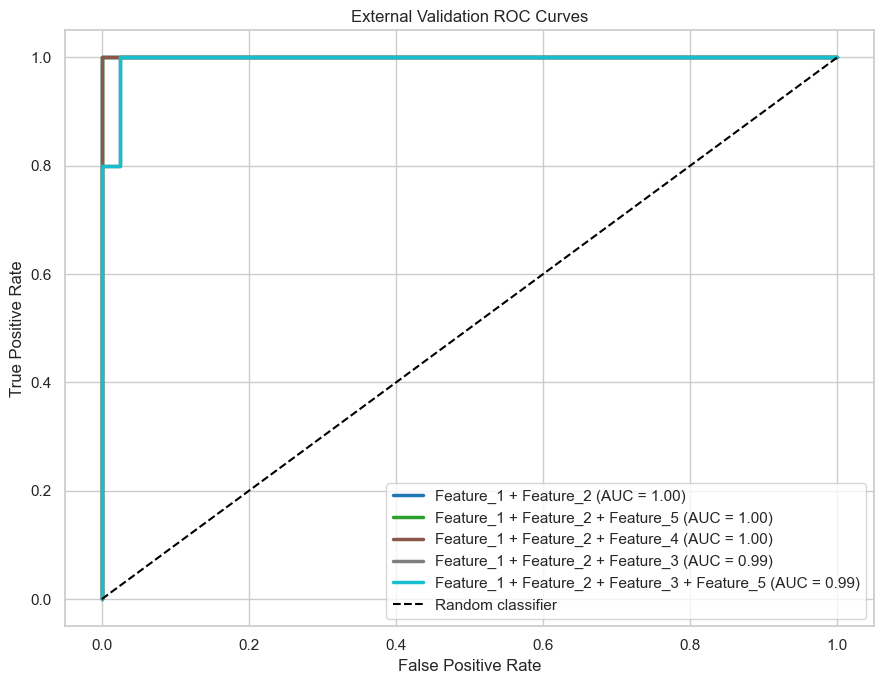

In [20]:
X_external_array, y_external_array = make_classification(
    n_samples=50,
    n_features=5,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    weights=[0.8, 0.2],
    hypercube=True,
    shift=1.0,
    scale=1.5,
    shuffle=False,
    random_state=123,
)

X_external = pd.DataFrame(X_external_array, columns=feature_names)
y_external = pd.Series(y_external_array, name="Class")

external_results = []
external_roc_data = {}

for _, row in top_cv_models.iterrows():
    feature_combo = row["Features"].split(" + ")

    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000),
    )

    model.fit(X_df[feature_combo], y_series)
    y_external_prob = model.predict_proba(X_external[feature_combo])[:, 1]

    external_auc = roc_auc_score(y_external, y_external_prob)
    fpr, tpr, _ = roc_curve(y_external, y_external_prob)

    external_results.append({
        "Features": row["Features"],
        "Mean CV ROC AUC": row["Mean CV ROC AUC"],
        "External ROC AUC": external_auc,
    })

    external_roc_data[row["Features"]] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": external_auc,
    }

external_results_df = pd.DataFrame(external_results).sort_values(
    by="External ROC AUC",
    ascending=False,
)

display(external_results_df.round(3))

plt.figure(figsize=(9, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(external_results_df)))

for color, (_, row) in zip(colors, external_results_df.iterrows()):
    label = row["Features"]
    plt.plot(
        external_roc_data[label]["fpr"],
        external_roc_data[label]["tpr"],
        color=color,
        linewidth=2.5,
        label=f"{label} (AUC = {external_roc_data[label]['auc']:.2f})",
    )

plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1.5, label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("External Validation ROC Curves")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Comparing Classification Algorithms

Logistic regression is a good first model because it is simple and interpretable. Other classifiers may perform better if the signal is nonlinear or depends on interactions among features.

Here we compare logistic regression, random forest, and support vector machine classifiers using cross-validated predicted probabilities.


,Model,Cross-validated ROC AUC
0,Logistic Regression,0.999
2,SVM,0.985
1,Random Forest,0.976


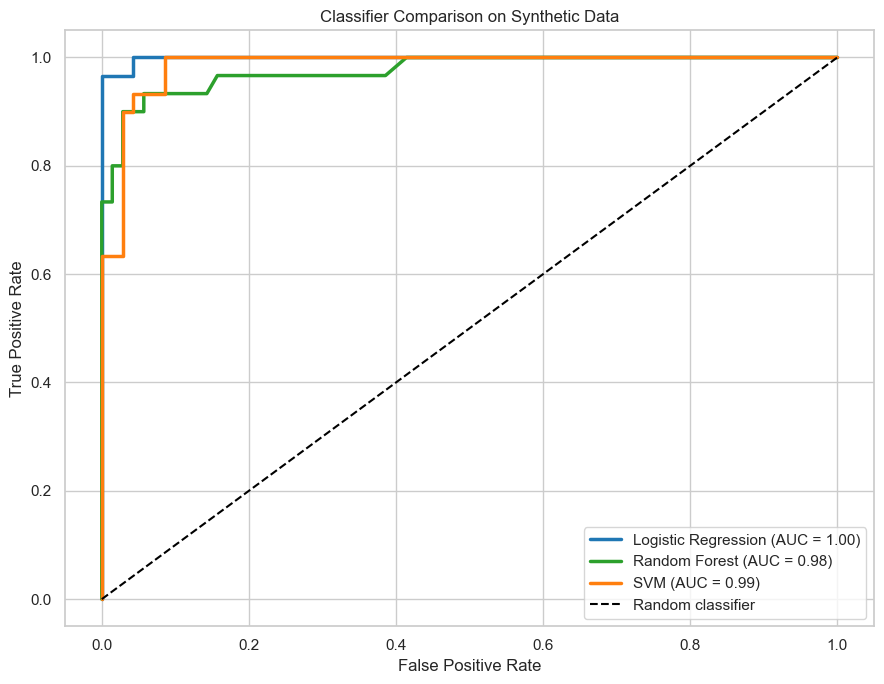

In [21]:
models = {
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000),
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
    ),
    "SVM": make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
    ),
}

model_comparison_rows = []
model_roc_data = {}

for model_name, model in models.items():
    y_prob = cross_val_predict(
        model,
        X_df,
        y_series,
        cv=cv,
        method="predict_proba",
    )[:, 1]

    auc = roc_auc_score(y_series, y_prob)
    fpr, tpr, _ = roc_curve(y_series, y_prob)

    model_comparison_rows.append({
        "Model": model_name,
        "Cross-validated ROC AUC": auc,
    })

    model_roc_data[model_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": auc,
    }

model_comparison_df = pd.DataFrame(model_comparison_rows).sort_values(
    by="Cross-validated ROC AUC",
    ascending=False,
)

display(model_comparison_df.round(3))

plt.figure(figsize=(9, 7))
colors = ["tab:blue", "tab:green", "tab:orange"]

for color, (model_name, data) in zip(colors, model_roc_data.items()):
    plt.plot(
        data["fpr"],
        data["tpr"],
        color=color,
        linewidth=2.5,
        label=f"{model_name} (AUC = {data['auc']:.2f})",
    )

plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1.5, label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Classifier Comparison on Synthetic Data")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Model Interpretation

Different classifiers expose different summaries:

- logistic regression has coefficients;
- random forest has feature importance scores;
- SVMs can be summarized by their support vectors, although nonlinear SVMs are less directly interpretable.

Permutation importance offers a model-agnostic way to ask how much performance drops when a feature is randomly shuffled.


In [22]:
fitted_models = {
    model_name: model.fit(X_df, y_series)
    for model_name, model in models.items()
}

lr_model = fitted_models["Logistic Regression"]
lr_coefficients = lr_model.named_steps["logisticregression"].coef_[0]
lr_summary = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lr_coefficients,
}).sort_values(by="Coefficient", ascending=False)

print("Logistic regression coefficients")
display(lr_summary.round(3))

rf_model = fitted_models["Random Forest"]
rf_summary = pd.DataFrame({
    "Feature": feature_names,
    "Random forest importance": rf_model.feature_importances_,
}).sort_values(by="Random forest importance", ascending=False)

print("Random forest feature importance")
display(rf_summary.round(3))

svm_model = fitted_models["SVM"]
print("SVM support vectors per class:", svm_model.named_steps["svc"].n_support_)
print("Total SVM support vectors:", svm_model.named_steps["svc"].support_vectors_.shape[0])

perm = permutation_importance(
    rf_model,
    X_df,
    y_series,
    n_repeats=100,
    random_state=RANDOM_STATE,
)

permutation_summary = pd.DataFrame({
    "Feature": feature_names,
    "Mean permutation importance": perm.importances_mean,
    "Std permutation importance": perm.importances_std,
}).sort_values(by="Mean permutation importance", ascending=False)

print("Random forest permutation importance")
display(permutation_summary.round(3))


Logistic regression coefficients


,Feature,Coefficient
1,Feature_2,3.461
3,Feature_4,-0.061
2,Feature_3,-0.357
4,Feature_5,-0.438
0,Feature_1,-0.950


Random forest feature importance


,Feature,Random forest importance
1,Feature_2,0.715
0,Feature_1,0.087
2,Feature_3,0.081
3,Feature_4,0.061
4,Feature_5,0.056


SVM support vectors per class: [26 19]
Total SVM support vectors: 45
Random forest permutation importance


,Feature,Mean permutation importance,Std permutation importance
1,Feature_2,0.405,0.047
0,Feature_1,0.025,0.009
2,Feature_3,0.008,0.007
4,Feature_5,0.004,0.005
3,Feature_4,0.000,0.000


## Part 2: Application to a Biomedical Dataset

Now we repeat the same workflow using the breast cancer dataset included with scikit-learn. The task is to classify tumors as malignant or benign using quantitative measurements from cell nuclei.

This dataset is useful for teaching because it is available offline, has a clear biological interpretation, and has enough features to discuss model selection.


Dataset shape: (569, 32)
Target counts:


,Count
target_name,
benign,357
malignant,212


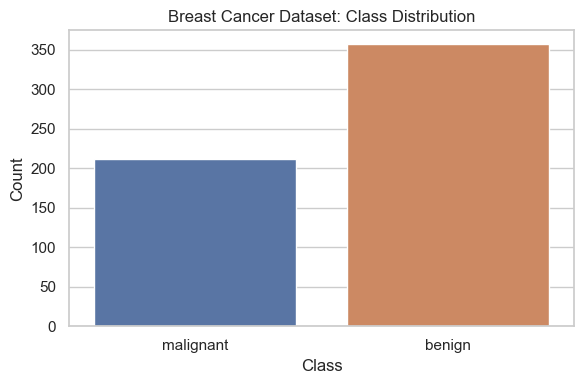

In [23]:
breast_cancer = load_breast_cancer()

bc_df = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
bc_df["target"] = breast_cancer.target
bc_df["target_name"] = bc_df["target"].map({0: "malignant", 1: "benign"})

print("Dataset shape:", bc_df.shape)
print("Target counts:")
display(bc_df["target_name"].value_counts().to_frame("Count"))

plt.figure(figsize=(6, 4))
sns.countplot(data=bc_df, x="target_name", order=["malignant", "benign"])
plt.title("Breast Cancer Dataset: Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## Feature Subset Search on the Breast Cancer Dataset

To keep the example interpretable, we again search over 1-, 2-, and 3-feature logistic regression models. This lets us ask a practical biological modeling question: how much performance can we get from a small, explainable panel of measurements?


Training set shape: (455, 30)
Test set shape: (114, 30)
Top breast-cancer feature panels


,Num Features,Features,Test ROC AUC
2733,3,mean concavity + worst area + worst smoothness,0.996
2964,3,mean concave points + worst area + worst smoothness,0.996
1222,3,mean texture + worst perimeter + worst smoothness,0.996
4442,3,worst texture + worst perimeter + worst smoothness,0.996
4410,3,worst radius + worst texture + worst concave points,0.995
3818,3,perimeter error + worst perimeter + worst smoothness,0.995
4451,3,worst texture + worst area + worst concave points,0.995
4448,3,worst texture + worst area + worst smoothness,0.995
1207,3,mean texture + worst radius + worst smoothness,0.995
2727,3,mean concavity + worst perimeter + worst smoothness,0.995


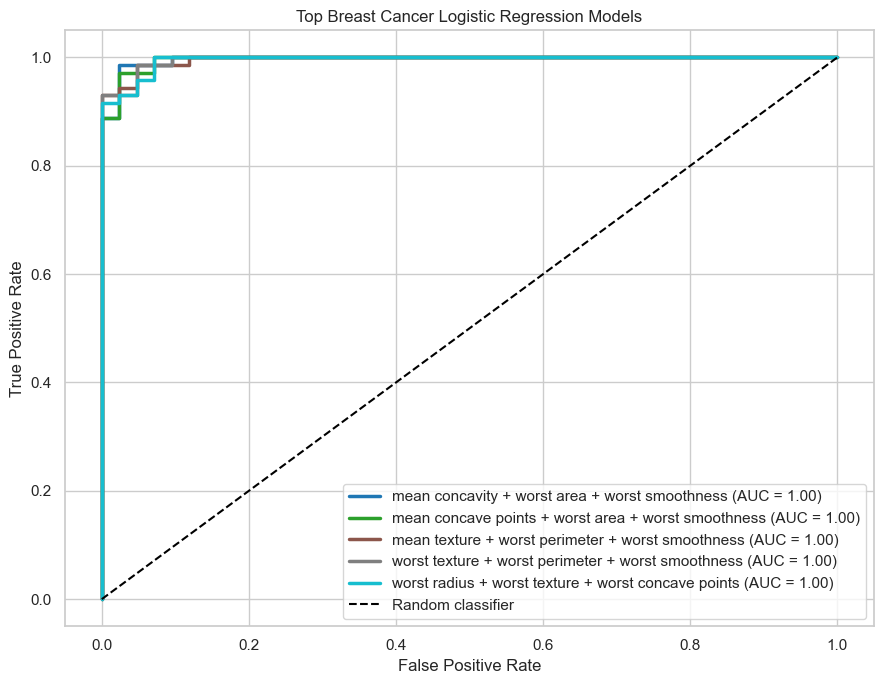

In [24]:
bc_X = bc_df.drop(columns=["target", "target_name"])
bc_y = bc_df["target"]

bc_X_train, bc_X_test, bc_y_train, bc_y_test = train_test_split(
    bc_X,
    bc_y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=bc_y,
)

print("Training set shape:", bc_X_train.shape)
print("Test set shape:", bc_X_test.shape)

bc_results = []
bc_roc_data = {}

for n_features in [1, 2, 3]:
    for feature_combo in combinations(bc_X_train.columns, n_features):
        feature_name = " + ".join(feature_combo)

        model = make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=1000),
        )

        model.fit(bc_X_train[list(feature_combo)], bc_y_train)
        bc_y_prob = model.predict_proba(bc_X_test[list(feature_combo)])[:, 1]

        auc = roc_auc_score(bc_y_test, bc_y_prob)
        fpr, tpr, _ = roc_curve(bc_y_test, bc_y_prob)

        bc_results.append({
            "Num Features": n_features,
            "Features": feature_name,
            "Test ROC AUC": auc,
        })

        bc_roc_data[feature_name] = {
            "fpr": fpr,
            "tpr": tpr,
            "auc": auc,
            "model": model,
        }

bc_results_df = pd.DataFrame(bc_results).sort_values(
    by="Test ROC AUC",
    ascending=False,
)

print("Top breast-cancer feature panels")
display(bc_results_df.head(10).round(3))

bc_top_models = bc_results_df.head(5)

plt.figure(figsize=(9, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(bc_top_models)))

for color, (_, row) in zip(colors, bc_top_models.iterrows()):
    label = row["Features"]
    plt.plot(
        bc_roc_data[label]["fpr"],
        bc_roc_data[label]["tpr"],
        color=color,
        linewidth=2.5,
        label=f"{label} (AUC = {bc_roc_data[label]['auc']:.2f})",
    )

plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1.5, label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Top Breast Cancer Logistic Regression Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [ ]:
best_bc_row = bc_results_df.iloc[0]
best_bc_features = best_bc_row["Features"].split(" + ")
best_bc_model = bc_roc_data[best_bc_row["Features"]]["model"]
best_bc_coefficients = best_bc_model.named_steps["logisticregression"].coef_[0]

best_bc_coef_df = pd.DataFrame({
    "Feature": best_bc_features,
    "Coefficient": best_bc_coefficients,
}).sort_values(by="Coefficient", ascending=False)

print("Best feature panel:", best_bc_row["Features"])
print("Best test ROC AUC:", round(best_bc_row["Test ROC AUC"], 3))
display(best_bc_coef_df.round(3))

plt.figure(figsize=(7, 4))
plt.barh(best_bc_coef_df["Feature"], best_bc_coef_df["Coefficient"])
plt.gca().invert_yaxis()
plt.xlabel("Coefficient")
plt.title("Coefficients for Best Breast Cancer Model")
plt.tight_layout()
plt.show()

print("Best single-feature breast-cancer models")
display(
    bc_results_df.loc[bc_results_df["Num Features"] == 1]
    .sort_values(by="Test ROC AUC", ascending=False)
    .head(10)
    .round(3)
)


## Connection to Neural Networks

A neural network with a single sigmoid output node and binary cross-entropy loss is closely related to logistic regression. If there are no hidden layers, the model is essentially learning a linear decision boundary followed by a sigmoid transformation.

Hidden layers make neural networks more flexible, but they also make model interpretation and validation more challenging. For many biological modeling problems, logistic regression is still a strong baseline.


## Take-Home Points

- Logistic regression is a useful first classifier because it is interpretable and performs well on many biological datasets.
- Feature selection should be evaluated with validation data, not just univariate tests.
- Cross-validation is useful for model selection, but external validation is a stronger test of generalization.
- More complex classifiers are worth comparing, but they are not automatically better.
- Small, interpretable feature panels can be scientifically valuable even when larger models are available.
